In [11]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import zlib
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [2]:
def count_cut_permutation(ts, window):
    if window == 3:
        c_p = count_permutation(ts, 3)
        return [c_p[0], c_p[1]+c_p[3], c_p[2]+c_p[4], c_p[5]]
    if window == 4:
        c_p = count_permutation(ts, 4)
        return [c_p[0], c_p[1]+c_p[3]+c_p[9], c_p[2]+c_p[4]+c_p[8]+c_p[10]+c_p[16], c_p[5]+c_p[11]+c_p[17], c_p[6]+c_p[12]+c_p[18], c_p[7]+c_p[13]+c_p[15]+c_p[19]+c_p[21], c_p[14]+c_p[22]+c_p[20], c_p[23]]
def new_permutation_entropy(ts, window):
    return entropy(count_cut_permutation(ts,window))
def new_permutation_series(ts: pd.Series, window: int) -> pd.Series:
    r = list(range(window))
    permutation_list = list(it.permutations(r))
    pseries = []
    real_ts = remove_consecutive_duplicates(ts.copy())
    for i in range(real_ts.size - window + 1):
        slice_df = real_ts.copy().iloc[i:i + window]
        sort_slice = slice_df.copy().sort_values()
        for j in range(window):
            slice_df[slice_df[slice_df == sort_slice.iloc[j]].first_valid_index()] = j
        pseries.append(permutation_list.index(tuple(slice_df.tolist())))
    if window == 3:
        change_dict = {0:0, 1:1, 2:2, 3:1, 4:2, 5:3}
        return pd.Series(pseries).map(change_dict)
    if window == 4:
        change_dict = {0:0, 1:1, 2:2, 3:1, 9:1, 4:2, 8:2, 10:2, 16:2, 5:3, 11:3, 17:3, 6:4, 12:4, 18:4, 7:5, 13:5, 15:5, 19:5, 21:5, 14:6, 22:6, 20:6, 23:7}
        return pd.Series(pseries).map(change_dict)

In [3]:
rw = generate_rw(1000)
p_s = new_permutation_series(rw, 3)

In [10]:
data = "".join(list(map(str,p_s.tolist())))
data

'12132012000132120001201200013321321212012013201212013212000120000001212012012132001200012132012001320000120001212013212001200001321200121201332012132121212013332120012000001333333333321201212000120120132012000001212120120012121212012132001201212133213200121332121320001320132133320000001333213200001200013201321320133321320133320013332013333320013321332000001332132132132001320000013332013320132012133201332001332001320012013213321320001201213332120121201201321332012013320133212121201332120120133321332132013212133332012120133213321200012013201201321201333213332133213200120001332133333213200132012012120001200001321213200132121333213333320000120012132120013212132001321321201332120000133200121321321321332012013200001321321320132120132012013212132013201333212001332000121201333321333320001320000000013213213213332120132012012013213213201333212120001212001321332000133201332120000121332012000001201200000133333321333200013320012121321201320001212000013321332013320121201320013332133200013212001320'

In [13]:
byte_data = data.encode('utf-8')
compressed_data = zlib.compress(byte_data)
decompressed_data = zlib.decompress(compressed_data)

print(f"Original size: {len(byte_data)}")
print(f"Compressed size: {len(compressed_data)}")
print(f"Decompressed data equals original: {decompressed_data == byte_data}")

Original size: 998
Compressed size: 230
Decompressed data equals original: True


In [15]:
compression_ratio3_rw = []
compression_ratio4_rw = []
compression_ratio3_arma = []
compression_ratio4_arma = []
compression_ratio3_cos = []
compression_ratio4_cos = []
for length in [10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000]:
    print(length)
    rw = generate_rw(length)
    p_s = new_permutation_series(rw, 3)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio3_rw.append(len(compressed_data)/len(byte_data))
    p_s = new_permutation_series(rw, 4)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio4_rw.append(len(compressed_data)/len(byte_data))
    
    arma_ts = generate_arma(10, 5, length)
    p_s = new_permutation_series(arma_ts, 3)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio3_arma.append(len(compressed_data)/len(byte_data))
    p_s = new_permutation_series(arma_ts, 4)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio4_arma.append(len(compressed_data)/len(byte_data))
    
    _, cos_ts = generate_trend_series(length=length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.2,high=0.5))
    p_s = new_permutation_series(cos_ts, 3)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio3_cos.append(len(compressed_data)/len(byte_data))
    p_s = new_permutation_series(cos_ts, 4)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio4_cos.append(len(compressed_data)/len(byte_data))

10
30
50
100
250
500
750
1000
1500
2000
2500
3000


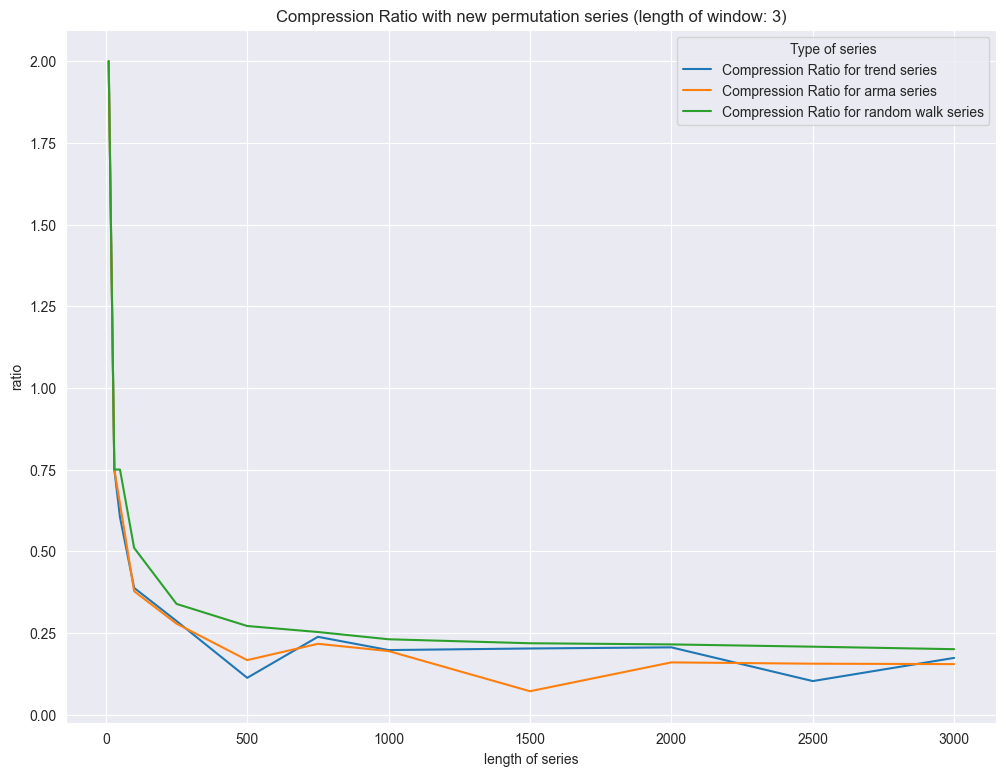

In [17]:
plt.figure(figsize=(12,9))
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio3_cos, label="Compression Ratio for trend series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio3_arma, label="Compression Ratio for arma series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio3_rw, label="Compression Ratio for random walk series")

plt.title("Compression Ratio with new permutation series (length of window: 3)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

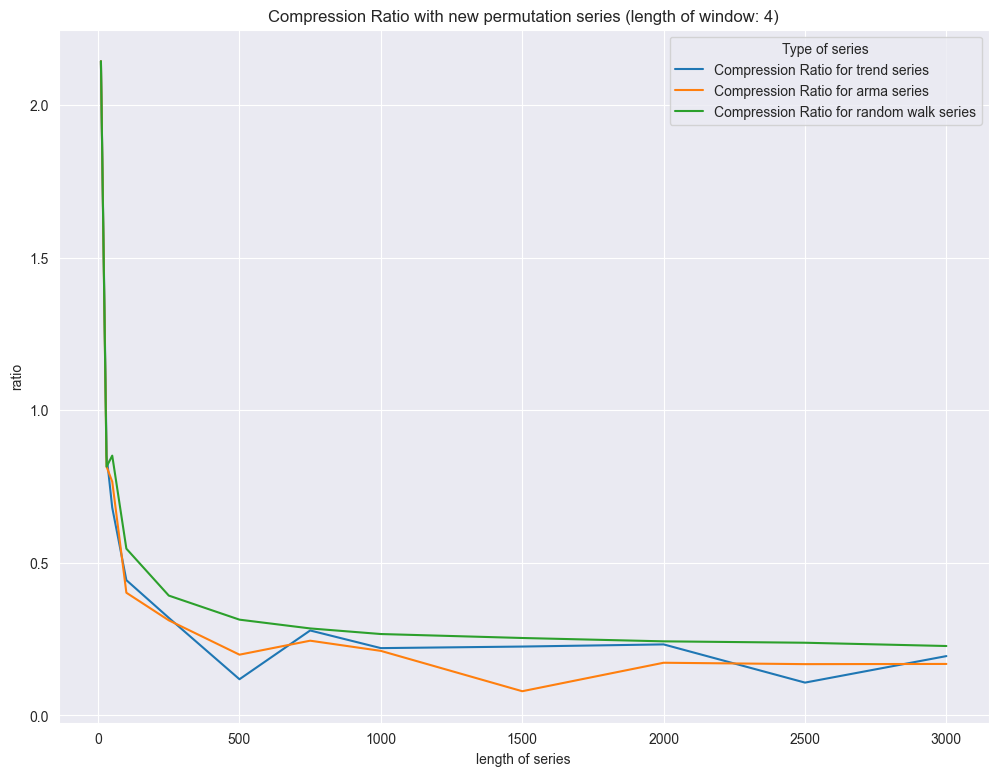

In [19]:
plt.figure(figsize=(12,9))
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio4_cos, label="Compression Ratio for trend series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio4_arma, label="Compression Ratio for arma series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio4_rw, label="Compression Ratio for random walk series")

plt.title("Compression Ratio with new permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

In [20]:
compression_ratio3_rw = []
compression_ratio4_rw = []
compression_ratio3_arma = []
compression_ratio4_arma = []
compression_ratio3_cos = []
compression_ratio4_cos = []
for length in [10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000]:
    print(length)
    rw = generate_rw(length)
    p_s = permutation_series(rw, 3)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio3_rw.append(len(compressed_data)/len(byte_data))
    p_s = permutation_series(rw, 4)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio4_rw.append(len(compressed_data)/len(byte_data))
    
    arma_ts = generate_arma(10, 5, length)
    p_s = permutation_series(arma_ts, 3)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio3_arma.append(len(compressed_data)/len(byte_data))
    p_s = permutation_series(arma_ts, 4)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio4_arma.append(len(compressed_data)/len(byte_data))
    
    _, cos_ts = generate_trend_series(length=length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.2,high=0.5))
    p_s = permutation_series(cos_ts, 3)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio3_cos.append(len(compressed_data)/len(byte_data))
    p_s = permutation_series(cos_ts, 4)
    data = "".join(list(map(str,p_s.tolist())))
    byte_data = data.encode('utf-8')
    compressed_data = zlib.compress(byte_data)
    compression_ratio4_cos.append(len(compressed_data)/len(byte_data))

10
30
50
100
250
500
750
1000
1500
2000
2500
3000


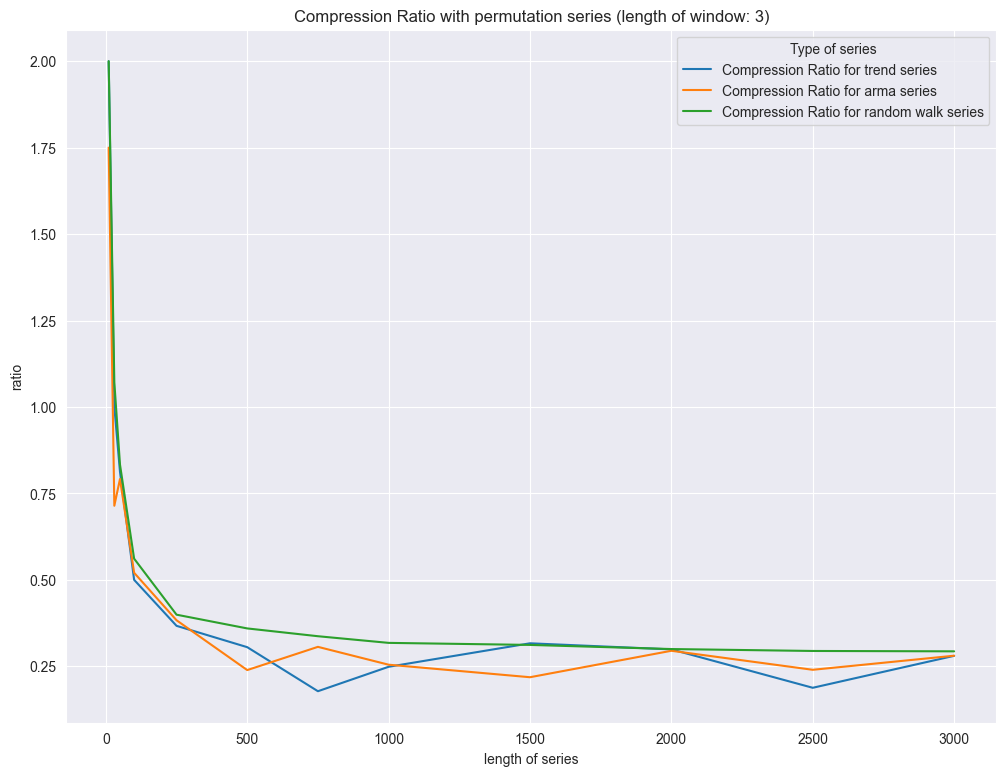

In [21]:
plt.figure(figsize=(12,9))
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio3_cos, label="Compression Ratio for trend series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio3_arma, label="Compression Ratio for arma series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio3_rw, label="Compression Ratio for random walk series")

plt.title("Compression Ratio with permutation series (length of window: 3)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

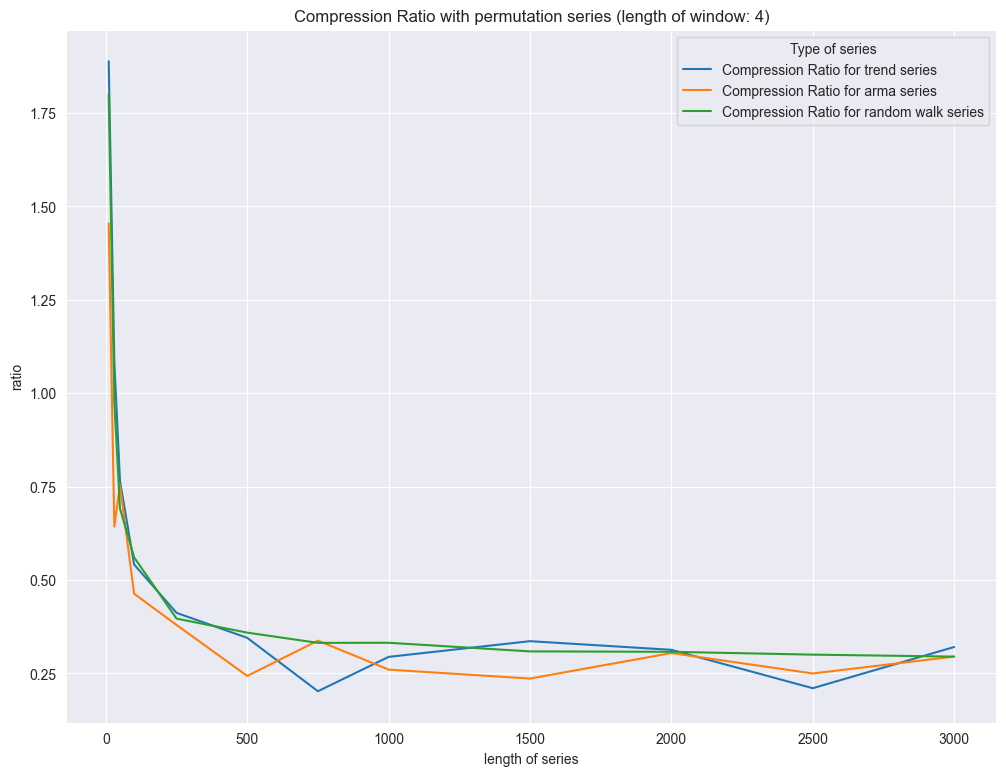

In [22]:
plt.figure(figsize=(12,9))
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio4_cos, label="Compression Ratio for trend series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio4_arma, label="Compression Ratio for arma series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio4_rw, label="Compression Ratio for random walk series")

plt.title("Compression Ratio with permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

Time Series
[ 0.3941381  -0.5550212   0.67632497  0.09097672  0.66875783  1.24088193
 -0.47479963  0.93328375  1.08179028  2.25835178  3.33133353  1.70915749
  2.90711995  2.35151147  1.22238283  1.55066515  0.96121972  0.87403973
  0.15432443  1.79126528]
Quantized time series
[ 0.         -0.97158868  0.97158868  0.          0.97158868  0.97158868
 -0.          0.97158868  0.97158868  1.94317736  2.91476605  1.94317736
  2.91476605  1.94317736  0.97158868  1.94317736  0.97158868  0.97158868
  0.          1.94317736]


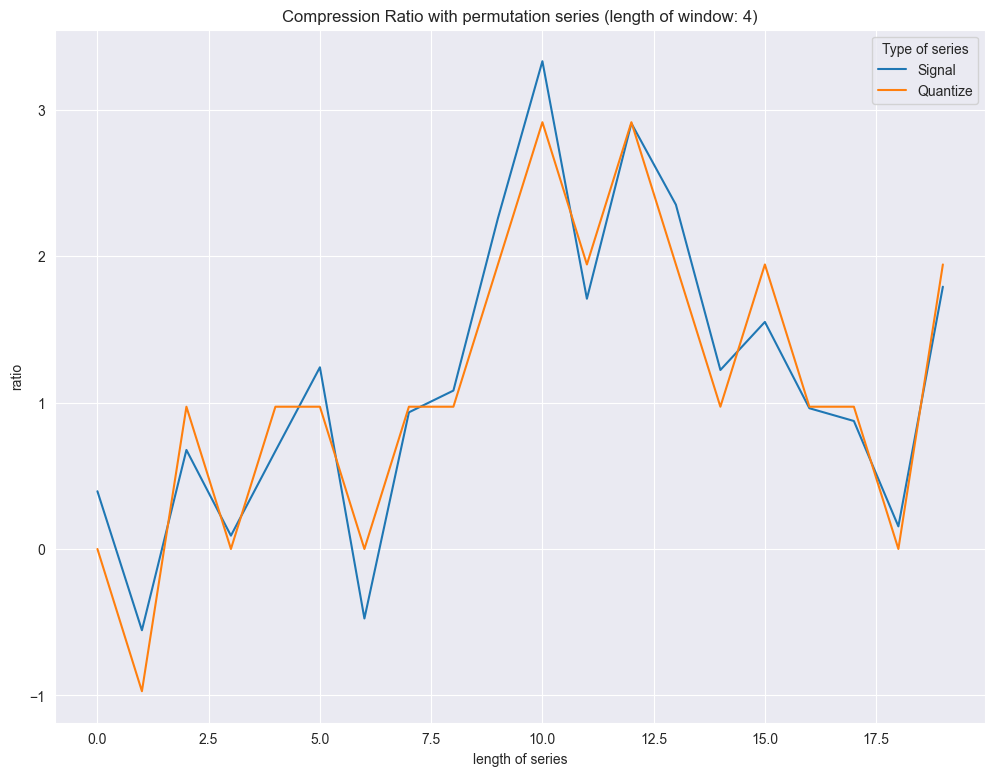

In [31]:
def uniform_quantize(signal, levels):
    x_min, x_max = np.min(signal), np.max(signal)
    step_size = (x_max - x_min) / levels
    quantized_signal = step_size * np.round(signal / step_size)
    return quantized_signal

signal = generate_rw(20)
levels = 4
quantized_signal = uniform_quantize(signal, levels)
print("Time Series")
print(signal)
print("Quantized time series")
print(quantized_signal)
plt.figure(figsize=(12, 9))
sns.lineplot(x=np.arange(len(signal)), y=signal, label="Signal")
sns.lineplot(x=np.arange(len(signal)), y=quantized_signal, label="Quantize")

plt.title("Compression Ratio with permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

Time Series
[-3.29601752 -4.84189031 -3.53653322 -4.36502885 -5.25544407 -5.21670464
 -4.80584233 -4.93312692 -5.46472381 -5.03216024 -4.76929728 -3.59147346
 -4.12452058 -4.07990368 -2.73249877 -3.27884812 -2.7054999  -1.93991151
 -1.79724376 -1.09148835]
Quantized time series
[-27 -36 -29 -34 -38 -38 -36 -37 -39 -37 -36 -29 -33 -32 -23 -27 -23 -15
 -13  -2]
Dequantized time series
[-3.24455705 -4.80085749 -3.53977335 -4.40058345 -5.23750777 -5.23750777
 -4.80085749 -5.01443573 -5.47049564 -5.01443573 -4.80085749 -3.53977335
 -4.21313039 -4.03365523 -2.72585679 -3.24455705 -2.72585679 -1.92370158
 -1.76311615 -1.09123471]


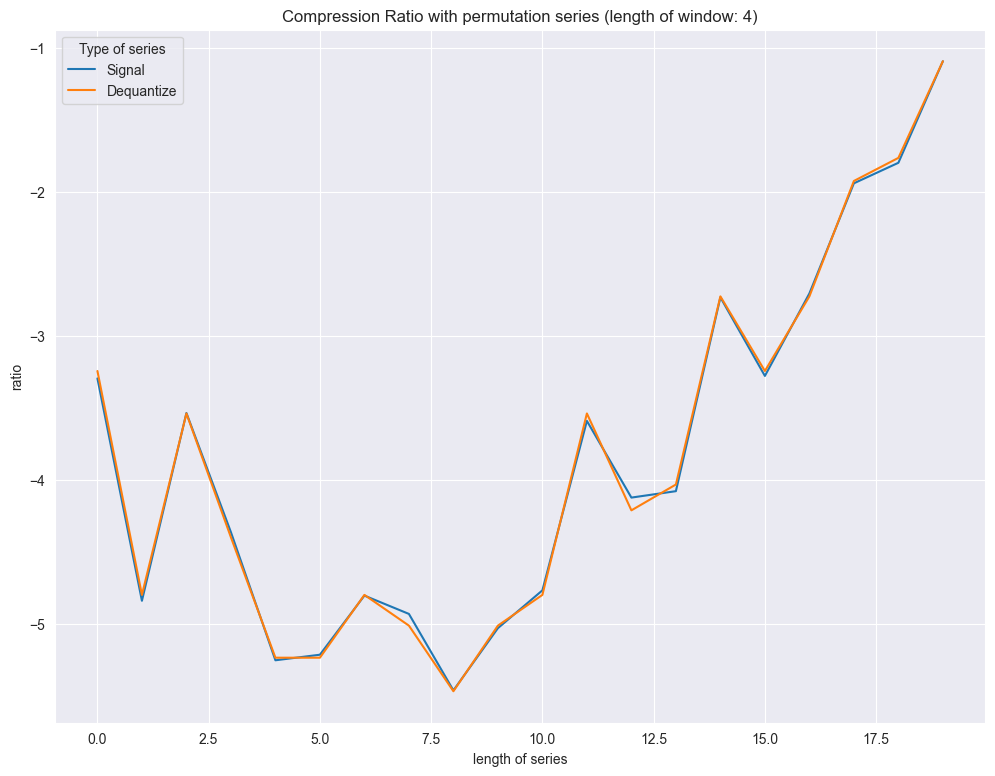

In [34]:
def mu_law_quantize(signal, mu=255):
    signal = np.sign(signal) * np.log1p(mu * np.abs(signal)) / np.log1p(mu)
    signal = np.round((signal + 1) * 127.5).astype(np.int64)
    return signal

def mu_law_dequantize(signal, mu=255):
    signal = signal / 127.5 - 1
    signal = np.sign(signal) * (np.expm1(np.abs(signal) * np.log1p(mu)) / mu)
    return signal

signal = generate_rw(20)
quantized_signal = mu_law_quantize(signal)
dequantized_signal = mu_law_dequantize(quantized_signal)
print("Time Series")
print(signal)
print("Quantized time series")
print(quantized_signal)
print("Dequantized time series")
print(dequantized_signal)
plt.figure(figsize=(12, 9))
sns.lineplot(x=np.arange(len(signal)), y=signal, label="Signal")
sns.lineplot(x=np.arange(len(signal)), y=dequantized_signal, label="Dequantize")

plt.title("Compression Ratio with permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

Time Series
[-1.03408513 -1.35812889 -2.69263826 -3.08275383 -3.0507123  -0.43218455
 -0.85502536 -1.71270332 -0.11522241  0.42976854 -0.81646162  1.30404951
  1.33051749  2.42446492  0.86508257  1.55003218  1.80892239  4.33319918
  3.76486103  1.93089808]
Quantized time series
[ -1  -7 -23 -26 -26  20   4 -13  50 235   5 261 262 276 252 265 269 289
 286 270]
Dequantized time series
[-1.04385832 -1.35048854 -2.68383507 -3.05267448 -3.05267448 -0.42380771
 -0.84223594 -1.74719045 -0.11692897  0.42380771 -0.8068489   1.29374697
  1.35048854  2.46304705  0.87917499  1.53608616  1.82381929  4.3034123
  3.78345248  1.90380895]


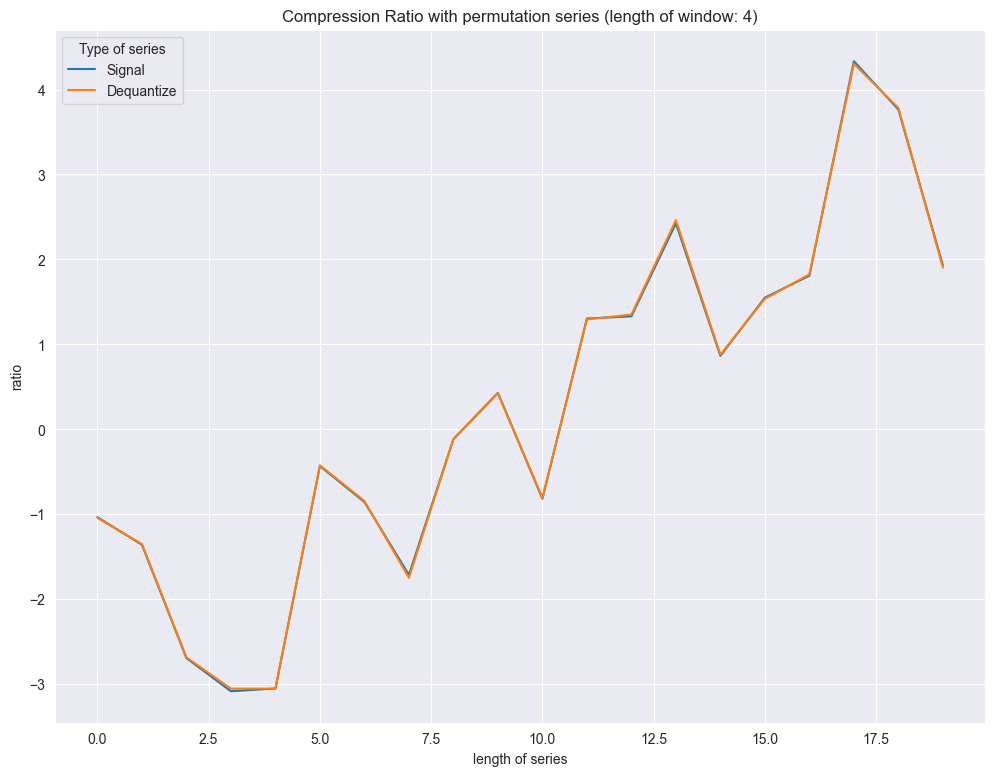

In [35]:
def a_law_quantize(signal, A=87.6):
    abs_signal = np.abs(signal)
    compressed_signal = np.where(abs_signal < (1 / A), A * abs_signal / (1 + np.log(A)), (1 + np.log(A * abs_signal)) / (1 + np.log(A)))
    quantized_signal = np.sign(signal) * compressed_signal
    quantized_signal = np.round((quantized_signal + 1) * 127.5).astype(np.int64)
    return quantized_signal

def a_law_dequantize(signal, A=87.6):
    signal = signal / 127.5 - 1
    abs_signal = np.abs(signal)
    expanded_signal = np.where(abs_signal < (1 / (1 + np.log(A))), abs_signal * (1 + np.log(A)) / A, np.exp(abs_signal * (1 + np.log(A)) - 1) / A)
    dequantized_signal = np.sign(signal) * expanded_signal
    return dequantized_signal

signal = generate_rw(20)
quantized_signal = a_law_quantize(signal)
dequantized_signal = a_law_dequantize(quantized_signal)
print("Time Series")
print(signal)
print("Quantized time series")
print(quantized_signal)
print("Dequantized time series")
print(dequantized_signal)
plt.figure(figsize=(12, 9))
sns.lineplot(x=np.arange(len(signal)), y=signal, label="Signal")
sns.lineplot(x=np.arange(len(signal)), y=dequantized_signal, label="Dequantize")

plt.title("Compression Ratio with permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

Time Series
[ 1.0826025   0.48494429  1.31854088  1.81750411  1.53811726  2.75911696
  2.29123488  2.28097275  3.05993566  1.54502506  0.0837431   1.34842184
  0.21124033  0.68195384  0.57926407 -0.71258665  0.78640163  1.29287658
  3.39459607  2.35761329]
Quantized time series
[ 0.52988291  1.26291829  1.80809083  1.4868852   2.78072307  2.3286625
  2.3310522   2.98375112  1.62746656  0.          1.40078932  0.26001408
  0.81675989  0.55009812 -0.62116258  0.71427413  1.12567549  3.17860876
  2.50587501]


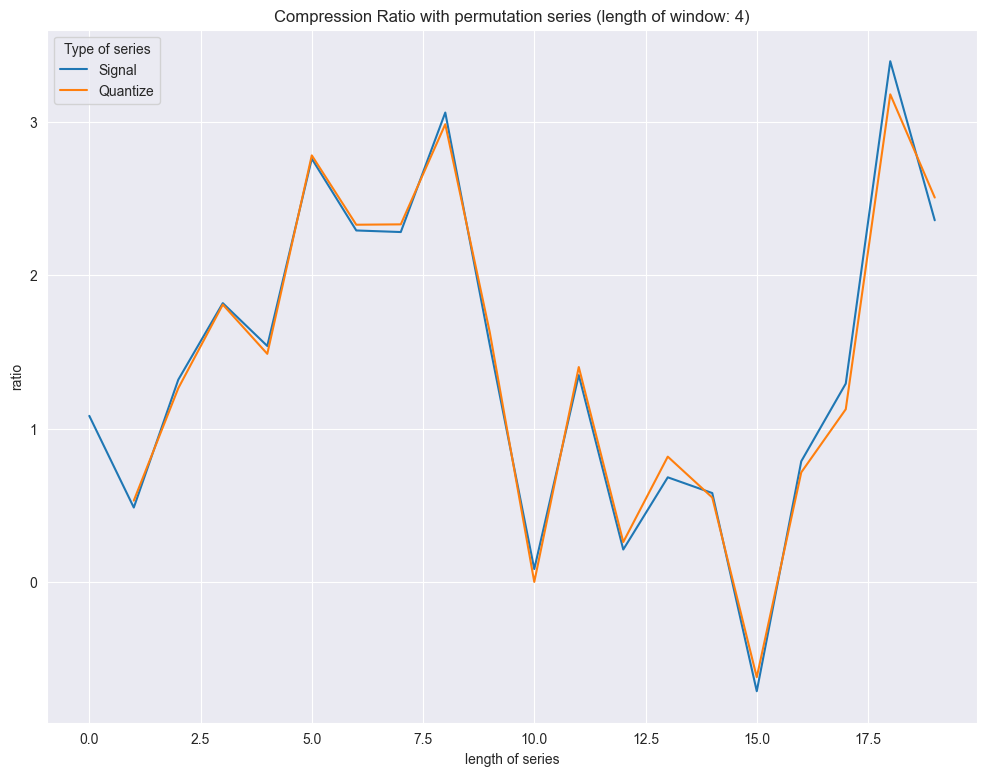

In [41]:
def adaptive_quantize(signal, initial_step=0.1, adaptation_rate=0.1):
    quantized_signal = []
    step_size = initial_step

    for i in range(1, len(signal)):
        step_size = step_size * (1 + adaptation_rate * np.abs(signal[i] - signal[i-1]))
        quantized_signal.append(step_size * np.round(signal[i] / step_size))
        
    return np.array(quantized_signal)

signal = generate_rw(20)
quantized_signal = adaptive_quantize(signal)
print("Time Series")
print(signal)
print("Quantized time series")
print(quantized_signal)
plt.figure(figsize=(12, 9))
sns.lineplot(x=np.arange(len(signal)), y=signal, label="Signal")
sns.lineplot(x=np.arange(len(quantized_signal)+1)[1:], y=quantized_signal, label="Quantize")
plt.title("Compression Ratio with permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

Time Series
[ 1.35574703 -0.04349919 -1.05299462 -0.60305631 -1.97739221 -3.10615292
 -2.94814103 -3.28228826 -3.74714548 -5.81600024 -5.8926135  -5.4508333
 -6.46462208 -6.69263532 -7.96486048 -8.85319797 -7.47989707 -7.39254375
 -6.79814302 -7.65467657]
Quantized time series
[ 0.65612392  0.65612392 -1.21114771 -1.21114771 -1.21114771 -3.27093192
 -3.27093192 -3.27093192 -3.27093192 -6.18580791 -6.18580791 -6.18580791
 -6.18580791 -6.18580791 -7.86903517 -7.86903517 -7.86903517 -7.86903517
 -6.18580791 -7.86903517]
Codebook
[[ 0.65612392]
 [-6.18580791]
 [-7.86903517]
 [-1.21114771]
 [-3.27093192]]


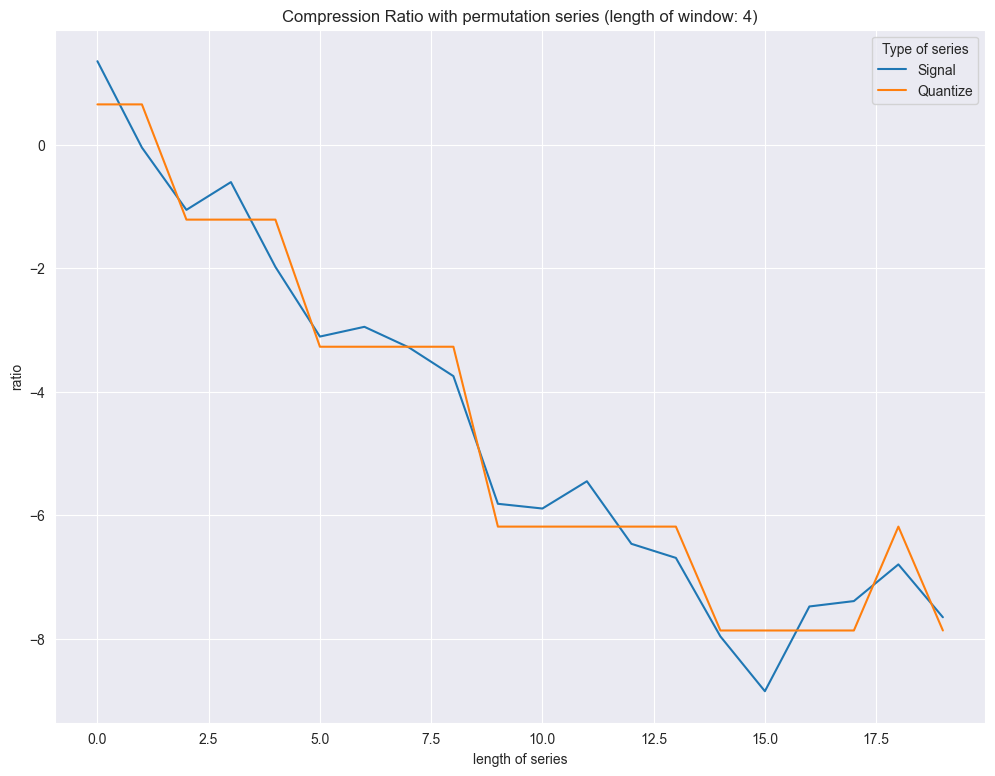

In [42]:
from sklearn.cluster import KMeans

def vector_quantize(signal, num_clusters):
    kmeans = KMeans(n_clusters=num_clusters)
    signal = signal.reshape(-1, 1)
    kmeans.fit(signal)
    quantized_signal = kmeans.cluster_centers_[kmeans.predict(signal)].flatten()
    return quantized_signal, kmeans.cluster_centers_

signal = generate_rw(20)
num_clusters = 5
quantized_signal, codebook = vector_quantize(signal, num_clusters)
print("Time Series")
print(signal)
print("Quantized time series")
print(quantized_signal)
print("Codebook")
print(codebook)
plt.figure(figsize=(12, 9))
sns.lineplot(x=np.arange(len(signal)), y=signal, label="Signal")
sns.lineplot(x=np.arange(len(quantized_signal)), y=quantized_signal, label="Quantize")
plt.title("Compression Ratio with permutation series (length of window: 4)")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()

In [90]:
rw = generate_rw(100)
quantized_signal, codebook = vector_quantize(rw, num_clusters)
byte_data = rw.tobytes()
byte_quant_data = quantized_signal.tobytes()
compressed_data = zlib.compress(byte_data)
compressed_quant_data = zlib.compress(byte_quant_data)
print('len raw ts:', len(byte_data))
print('len compressed raw ts:', len(compressed_data))
print('compression ratio:', len(compressed_data)/len(byte_data))
print('len ts:', len(byte_quant_data))
print('len compressed ts:', len(compressed_quant_data))
print('compression ratio:', len(compressed_quant_data)/len(byte_quant_data))

len raw ts: 800
len compressed raw ts: 811
compression ratio: 1.01375
len ts: 800
len compressed ts: 125
compression ratio: 0.15625


In [100]:
rw = generate_arma(10, 5, 100)
quantized_signal, codebook = vector_quantize(rw, num_clusters)
byte_data = rw.tobytes()
byte_quant_data = quantized_signal.tobytes()
compressed_data = zlib.compress(byte_data)
compressed_quant_data = zlib.compress(byte_quant_data)
print('len raw ts:', len(byte_data))
print('len compressed raw ts:', len(compressed_data))
print('compression ratio:', len(compressed_data)/len(byte_data))
print('len ts:', len(byte_quant_data))
print('len compressed ts:', len(compressed_quant_data))
print('compression ratio:', len(compressed_quant_data)/len(byte_quant_data))

len raw ts: 800
len compressed raw ts: 811
compression ratio: 1.01375
len ts: 800
len compressed ts: 131
compression ratio: 0.16375


In [119]:
_, rw = generate_trend_series(length=100, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.2,high=0.5))
quantized_signal, codebook = vector_quantize(rw, num_clusters)
byte_data = rw.tobytes()
byte_quant_data = quantized_signal.tobytes()
compressed_data = zlib.compress(byte_data)
compressed_quant_data = zlib.compress(byte_quant_data)
print('len raw ts:', len(byte_data))
print('len compressed raw ts:', len(compressed_data))
print('compression ratio:', len(compressed_data)/len(byte_data))
print('len ts:', len(byte_quant_data))
print('len compressed ts:', len(compressed_quant_data))
print('compression ratio:', len(compressed_quant_data)/len(byte_quant_data))

len raw ts: 800
len compressed raw ts: 811
compression ratio: 1.01375
len ts: 800
len compressed ts: 77
compression ratio: 0.09625


In [127]:
compression_ratio_rw = []
compression_ratio_arma = []
compression_ratio_cos = []
for length in [10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000]:
    print(length)
    ratio_vec = []
    for i in range(10):
        rw = generate_rw(length)
        quantized_signal, codebook = vector_quantize(rw, len(rw)//4)
        byte_quant_data = quantized_signal.tobytes()
        compressed_quant_data = zlib.compress(byte_quant_data)
        ratio_vec.append(len(compressed_quant_data)/len(byte_quant_data))
    compression_ratio_rw.append(np.mean(ratio_vec))
    
    ratio_vec = []
    for i in range(10):
        rw = generate_arma(10, 5, length)
        quantized_signal, codebook = vector_quantize(rw, len(rw)//4)
        byte_quant_data = quantized_signal.tobytes()
        compressed_quant_data = zlib.compress(byte_quant_data)
        ratio_vec.append(len(compressed_quant_data)/len(byte_quant_data))
    compression_ratio_arma.append(np.mean(ratio_vec))
    
    ratio_vec = []
    for i in range(10):
        _, rw = generate_trend_series(length=length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.2,high=0.5))
        quantized_signal, codebook = vector_quantize(rw, len(rw)//4)
        byte_quant_data = quantized_signal.tobytes()
        compressed_quant_data = zlib.compress(byte_quant_data)
        ratio_vec.append(len(compressed_quant_data)/len(byte_quant_data))
    compression_ratio_cos.append(np.mean(ratio_vec))

10
30
50
100
250
500
750
1000
1500
2000
2500
3000


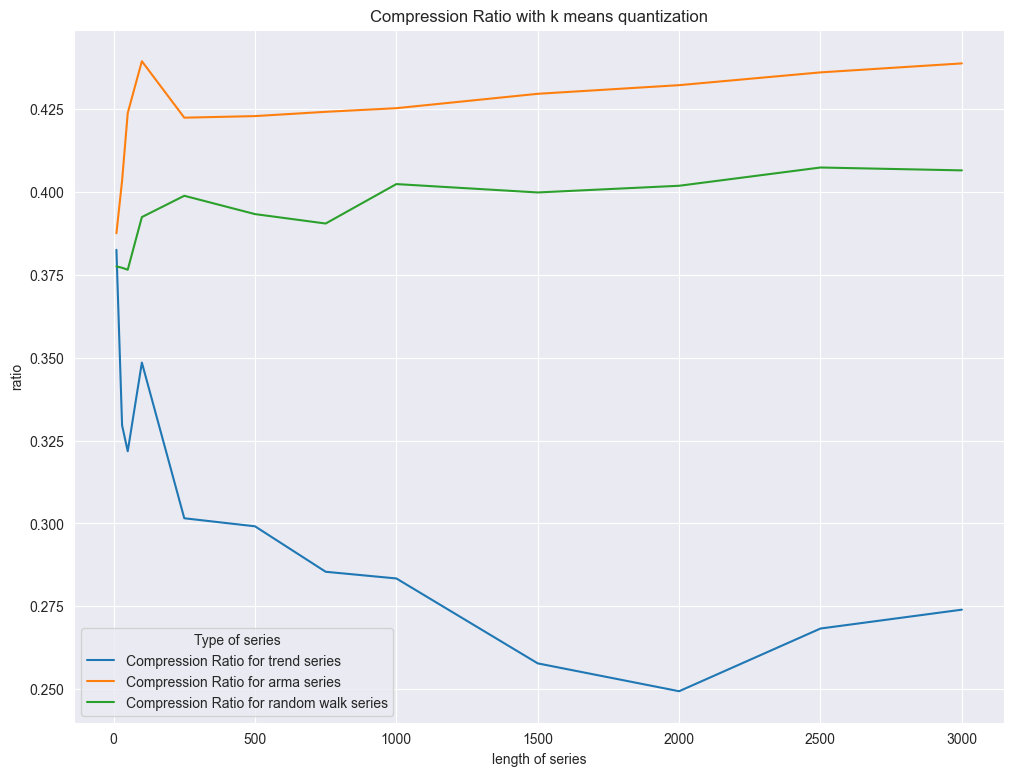

In [128]:
plt.figure(figsize=(12,9))
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio_cos, label="Compression Ratio for trend series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio_arma, label="Compression Ratio for arma series")
sns.lineplot(x=[10, 30, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000], y=compression_ratio_rw, label="Compression Ratio for random walk series")

plt.title("Compression Ratio with k means quantization")
plt.xlabel("length of series")
plt.ylabel("ratio")
plt.legend(title="Type of series")
plt.show()